### Loading Dataset

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("student-mat.csv", sep=';')
print(df.head())


  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


### Explore & Clean Data
Below, I check missing values,
       Removed Duplicates &
       Inspected Dataset Shape and Data types


In [12]:
print(df.isnull().sum())
df = df.drop_duplicates()
print(df.shape)
print(df.dtypes)

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
(395, 33)
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic 

### Question Analysis
*1. What is the average final grade (G3)?*
The overall average final grade for students in this dataset is approximately *10.42*.

*2. How many students scored above 15?*
There are exactly *40 students* who achieved a final grade higher than 15.

*3. Is study time correlated with performance?*
I calculated the correlation between study time and final grades (G3) and got a result of *0.097*. Because this number is so close to 0, it indicates that there is a very weak linear relationship between the recorded study time and the final score in this specific dataset. 

*4. Which gender performs better on average?*
When grouping the data by gender, *male students* performed slightly better on average with a mean score of *10.91*, compared to female students who had a mean score of *9.96*.

In [13]:
print("Average G3:", df['G3'].mean())
print("Students scoring > 15:", df[df['G3'] > 15].shape[0])
print("Study time / G3 Correlation:", df['studytime'].corr(df['G3']))
print(df.groupby('sex')['G3'].mean())

g3_std = np.std(df['G3'])
g3_variance = np.var(df['G3'])

print("\n--- NumPy Statistical Analysis ---")
print(f"Standard Deviation of Final Grades: {g3_std}")
print(f"Variance of Final Grades: {g3_variance}")

Average G3: 10.415189873417722
Students scoring > 15: 40
Study time / G3 Correlation: 0.09781968965319636
sex
F     9.966346
M    10.914439
Name: G3, dtype: float64

--- NumPy Statistical Analysis ---
Standard Deviation of Final Grades: 4.57563964146053
Variance of Final Grades: 20.936478128505044


### Visualizing Student Performance
"Below, I created a histogram to see the distribution of final grades (G3). Most students scored around the 10-11 mark. I also mapped study time against grades to find any correlations.

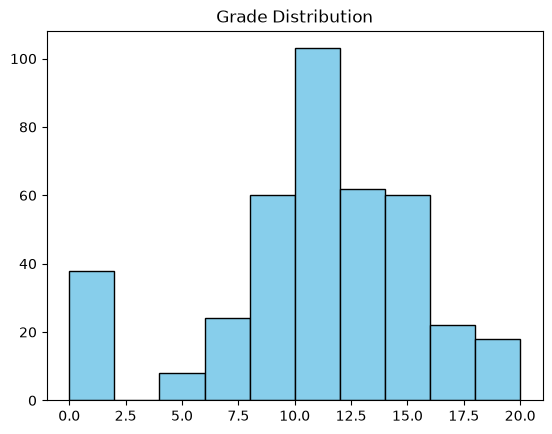

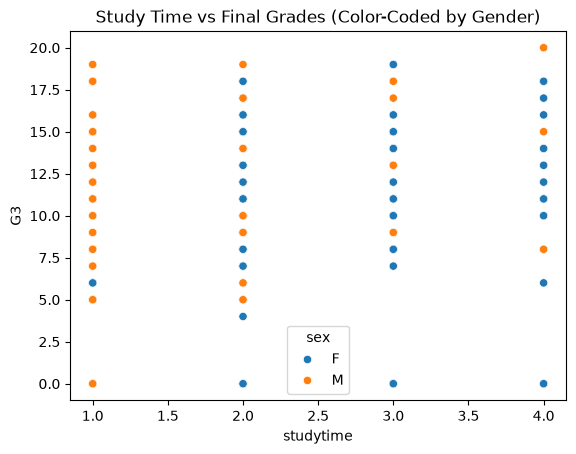

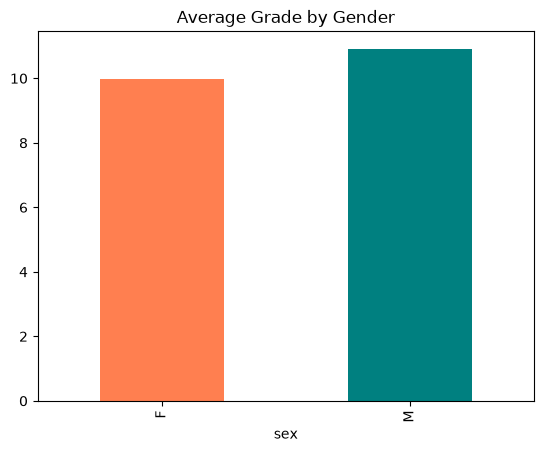

In [16]:
# Histogram
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black')
plt.title("Grade Distribution")
plt.show()

# Scatterplot
sns.scatterplot(x='studytime', y='G3', data=df, hue='sex')
plt.title("Study Time vs Final Grades (Color-Coded by Gender)")
plt.show()

# Bar Chart
df.groupby('sex')['G3'].mean().plot(kind='bar', color=['coral', 'teal'])
plt.title("Average Grade by Gender")
plt.show()